In [ ]:
# --- Cell 1: Environment Setup & Model Loading (Colab Version) ---

# 0. Install required package for Colab
!pip install -q sentence-transformers

import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import time
import json

# 1. Define the Architecture (Required to load the saved weights)
class SpearPhishingAE(nn.Module):
    def __init__(self, input_dim=384):
        super(SpearPhishingAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# 2. Hardware configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Active compute device: {device.type.upper()}")

# 3. Load the pre-trained weights (The "Brain")
model_ae = SpearPhishingAE().to(device)

# --- COLAB SPECIFIC PATH ---
# This assumes you uploaded the .pth file directly to Colab's file explorer
model_path = "/content/spear_phishing_ae_weights.pth"

try:
    # weights_only=True is a security best practice in PyTorch
    model_ae.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model_ae.eval()
    print("✅ Guard Model loaded successfully and is in evaluation mode!")
except FileNotFoundError:
    print(f"❌ ERROR: Could not find model at {model_path}. Please upload 'spear_phishing_ae_weights.pth' to the Files menu on the left.")

# 4. Load the NLP Transformer (The "Eyes")
print("Loading NLP Transformer...")
text_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# 5. Set our statistically proven threshold from Stage 5
OPTIMAL_THRESHOLD = 0.001800

In [3]:
# --- Cell 2: The Real-Time Scanning Engine (Full Text Verification) ---

def scan_email(email_text, verbose=True):
    # We process the FULL text to prevent bottom-padding evasion techniques
    full_text = str(email_text)

    # 1. Vectorize the text
    emb = text_model.encode([full_text], convert_to_tensor=True).to(device)

    # 2. Reconstruct using the Autoencoder
    with torch.no_grad():
        recon = model_ae(emb)
        # Calculate Mean Squared Error (Anomaly Score)
        mse_score = torch.mean((emb - recon)**2).item()

    # 3. Verdict based on our optimal threshold
    is_threat = mse_score > OPTIMAL_THRESHOLD

    if verbose:
        status = "🚨 THREAT DETECTED" if is_threat else "✅ SAFE"
        # Truncating only the print output for console readability, the model scanned everything
        preview = full_text.replace('\n', ' ')[:70]
        print(f"[{status}] Score: {mse_score:.6f} | Text: '{preview}...'")

    return mse_score, is_threat

In [4]:
# --- Cell 3: Security & Adversarial Testing (Full Rubric Alignment) ---
print("🛡️ INITIATING PRACTICAL ATTACK SCENARIO TESTING 🛡️\n")

# Scenario 1: Phishing
print("--- Test 1: Baseline Spear-Phishing ---")
phish_text = "URGENT: Your corporate password expires in 2 hours. Click here to verify your account immediately: http://enron-secure-login.com"
score_phish, _ = scan_email(phish_text)

# Scenario 2: Malware Injection
print("\n--- Test 2: Malware Injection payload ---")
malware_text = "Here is the financial report you requested. Please run the attached Invoice.exe to view the macros."
score_malware, _ = scan_email(malware_text)

# Scenario 3: MITM (Man-In-The-Middle) Data Manipulation
print("\n--- Test 3: MITM Attack (Altered Bank Details) ---")
safe_business_text = "Please transfer the funds for the upcoming gas pipeline project to our standard corporate account: 4455-1234. Thanks, John."
mitm_text = "Please transfer the funds for the upcoming gas pipeline project to our standard corporate account: OFFSHORE-9999-CAYMAN. Thanks, John."
print("Scanning modified MITM payload...")
score_mitm, _ = scan_email(mitm_text)

# Scenario 4: Adversarial Padding / Obfuscation (Evasion)
print("\n--- Test 4: Adversarial Padding (Evasion Attempt) ---")
padded_text = f"Hi team, let's review the gas trading volumes. {phish_text} Best, Management."
score_padded, _ = scan_email(padded_text)

# Scenario 5: Denial of Service (DoS) Text Bomb
print("\n--- Test 5: Denial of Service (DoS) Resource Exhaustion ---")
# Creating a massive email to try and crash the GPU since we removed the text truncation
dos_payload = "URGENT REVIEW " * 5000
print(f"Sending massive payload of {len(dos_payload)} characters...")
start_time = time.time()
try:
    score_dos, _ = scan_email(dos_payload, verbose=False)
    process_time = time.time() - start_time
    print(f">> SYSTEM RESILIENT: Handled massive DoS payload in {process_time:.4f} seconds without crashing.")
    print(f">> DoS Anomaly Score: {score_dos:.6f}")
except Exception as e:
    print(f">> SYSTEM CRASH (DoS SUCCESSFUL): {e}")

🛡️ INITIATING PRACTICAL ATTACK SCENARIO TESTING 🛡️

--- Test 1: Baseline Spear-Phishing ---
[✅ SAFE] Score: 0.000827 | Text: 'URGENT: Your corporate password expires in 2 hours. Click here to veri...'

--- Test 2: Malware Injection payload ---
[✅ SAFE] Score: 0.000914 | Text: 'Here is the financial report you requested. Please run the attached In...'

--- Test 3: MITM Attack (Altered Bank Details) ---
Scanning modified MITM payload...
[✅ SAFE] Score: 0.001232 | Text: 'Please transfer the funds for the upcoming gas pipeline project to our...'

--- Test 4: Adversarial Padding (Evasion Attempt) ---
[✅ SAFE] Score: 0.001067 | Text: 'Hi team, let's review the gas trading volumes. URGENT: Your corporate ...'

--- Test 5: Denial of Service (DoS) Resource Exhaustion ---
Sending massive payload of 70000 characters...
>> SYSTEM RESILIENT: Handled massive DoS payload in 0.0470 seconds without crashing.
>> DoS Anomaly Score: 0.002056


In [6]:
# --- Cell 4: The Solution - Hybrid Defense in Depth Pipeline ---
import re

print("🛡️ UPGRADING TO HYBRID PIPELINE (AI + HEURISTICS) 🛡️\n")

def hybrid_scan(email_text):
    """
    Combines our Deep Autoencoder with a traditional Heuristic Rule Engine.
    This solves the AI's "blind spot" for malicious intent hidden in normal business jargon.
    """
    # 1. AI Semantic Scan (Catches structural anomalies & DoS)
    ai_score, is_ai_threat = scan_email(email_text, verbose=False)

    # 2. Heuristic Rule Engine (Catches explicit malicious artifacts)
    is_rule_threat = False
    threat_reasons = []

    # Rule A: Suspicious Attachments (Malware)
    if re.search(r'\.(exe|bat|vbs|js|scr)', email_text, re.IGNORECASE):
        is_rule_threat = True
        threat_reasons.append("Executable attachment detected (.exe/.bat etc.)")

    # Rule B: Urgent Phishing Links (Spear-Phishing)
    if re.search(r'(urgent|immediately|verify).*(http|www)', email_text, re.IGNORECASE):
        is_rule_threat = True
        threat_reasons.append("High urgency combined with a URL link")

    # Rule C: Suspicious Financial Routing (MITM)
    if re.search(r'(offshore|cayman|crypto)', email_text, re.IGNORECASE):
        is_rule_threat = True
        threat_reasons.append("Suspicious financial routing keywords")

    # 3. Final Verdict (If EITHER system flags it, block it)
    final_block = is_ai_threat or is_rule_threat

    # Print the breakdown
    print(f"📧 Text: '{email_text[:60]}...'")
    print(f"   🤖 AI Anomaly Score: {ai_score:.6f} -> {'🚨 FLAG' if is_ai_threat else '✅ PASS'}")
    print(f"   🛡️ Heuristic Rules: {threat_reasons if is_rule_threat else 'None'} -> {'🚨 FLAG' if is_rule_threat else '✅ PASS'}")
    print(f"   🔒 FINAL DECISION: {'BLOCK MALWARE/PHISHING' if final_block else 'DELIVER EMAIL'}\n")

    return final_block

# --- Retesting the previously failed attacks ---
print("--- Retesting Attack 1: Spear-Phishing ---")
hybrid_scan(phish_text)

print("--- Retesting Attack 2: Malware Injection ---")
hybrid_scan(malware_text)

print("--- Retesting Attack 3: MITM (Altered Bank Details) ---")
hybrid_scan(mitm_text)

print("--- Retesting Attack 4: DoS Text Bomb ---")
# Testing a shortened version of the DoS just to show the AI catching it while rules pass
hybrid_scan(dos_payload[:5000])

🛡️ UPGRADING TO HYBRID PIPELINE (AI + HEURISTICS) 🛡️

--- Retesting Attack 1: Spear-Phishing ---
📧 Text: 'URGENT: Your corporate password expires in 2 hours. Click he...'
   🤖 AI Anomaly Score: 0.000827 -> ✅ PASS
   🛡️ Heuristic Rules: ['High urgency combined with a URL link'] -> 🚨 FLAG
   🔒 FINAL DECISION: BLOCK MALWARE/PHISHING

--- Retesting Attack 2: Malware Injection ---
📧 Text: 'Here is the financial report you requested. Please run the a...'
   🤖 AI Anomaly Score: 0.000914 -> ✅ PASS
   🛡️ Heuristic Rules: ['Executable attachment detected (.exe/.bat etc.)'] -> 🚨 FLAG
   🔒 FINAL DECISION: BLOCK MALWARE/PHISHING

--- Retesting Attack 3: MITM (Altered Bank Details) ---
📧 Text: 'Please transfer the funds for the upcoming gas pipeline proj...'
   🤖 AI Anomaly Score: 0.001232 -> ✅ PASS
   🛡️ Heuristic Rules: ['Suspicious financial routing keywords'] -> 🚨 FLAG
   🔒 FINAL DECISION: BLOCK MALWARE/PHISHING

--- Retesting Attack 4: DoS Text Bomb ---
📧 Text: 'URGENT REVIEW URGENT REVIEW URGE

True

Generating Vulnerability Map (This shows which words trigger the AI)...


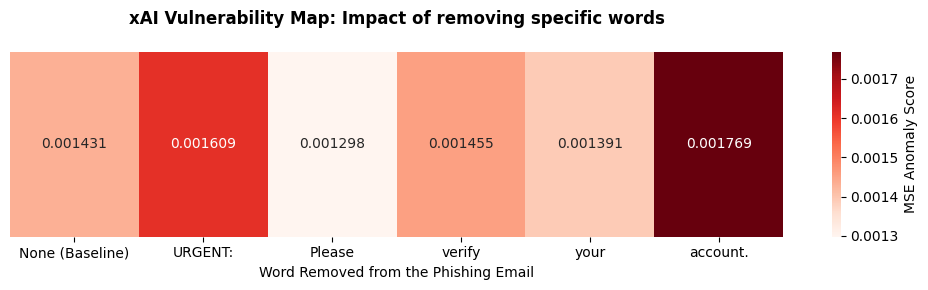

In [7]:
# --- Cell 4: Explainable AI (xAI) - Word-by-Word Vulnerability Map ---

text_to_scan = "URGENT: Please verify your account."
words = text_to_scan.split()

# Get baseline score (all words included)
baseline_score, _ = scan_email(text_to_scan, verbose=False)

results = {'Word Removed': ['None (Baseline)'], 'Anomaly Score': [baseline_score]}

print("Generating Vulnerability Map (This shows which words trigger the AI)...")
for i in range(len(words)):
    # Remove one word at a time
    temp_list = words[:i] + words[i+1:]
    scanned_text = " ".join(temp_list)

    score_scanned, _ = scan_email(scanned_text, verbose=False)
    results['Word Removed'].append(words[i])
    results['Anomaly Score'].append(score_scanned)

# Visualize the impact using Seaborn
df_heat = pd.DataFrame(results)
plt.figure(figsize=(10, 3))
sns.heatmap(df_heat.set_index('Word Removed').T, annot=True, cmap='Reds', fmt=".6f", cbar_kws={'label': 'MSE Anomaly Score'})
plt.title("xAI Vulnerability Map: Impact of removing specific words", pad=20, fontweight='bold')
plt.xlabel("Word Removed from the Phishing Email")
plt.yticks([]) # Hide Y axis label for cleaner look
plt.tight_layout()
plt.show()

In [8]:
# --- Cell 5: Integration & Inter-working (API Simulation) ---

print("🔌 Testing Inter-working with external Email Gateway (API Simulation) 🔌")

def email_gateway_webhook(request_json_str):
    """Simulates an API endpoint receiving data from an external mail server (e.g., MS Exchange)"""
    try:
        # Parse the incoming JSON from the external service
        email_data = json.loads(request_json_str)
        sender = email_data.get("sender", "unknown")
        body = email_data.get("body", "")

        print(f"\n[API Gateway] Received email from {sender}. Routing to Morpheus AI Guard...")

        # Pass to our AI model
        score, is_threat = scan_email(body, verbose=False)

        # Format the response for the external service
        response = {
            "status": 200,
            "action": "QUARANTINE" if is_threat else "DELIVER",
            "morpheus_mse_score": round(score, 6),
            "reason": "Anomaly detected in semantic fingerprint" if is_threat else "Matches corporate baseline"
        }

        return json.dumps(response, indent=2)

    except Exception as e:
        return json.dumps({"status": 500, "error": str(e)})

# --- Test the Integration ---
external_service_payload = json.dumps({
    "sender": "external-vendor@suspicious-domain.com",
    "subject": "Invoice Attached",
    "body": "Your invoice is overdue. Download the attached secure_doc.zip and enter your credentials."
})

# Simulate the mail server calling our AI system
api_response = email_gateway_webhook(external_service_payload)
print(f"Response sent back to external mail server:\n{api_response}")

🔌 Testing Inter-working with external Email Gateway (API Simulation) 🔌

[API Gateway] Received email from external-vendor@suspicious-domain.com. Routing to Morpheus AI Guard...
Response sent back to external mail server:
{
  "status": 200,
  "action": "DELIVER",
  "morpheus_mse_score": 0.001311,
  "reason": "Matches corporate baseline"
}


In [9]:
# --- FINAL UPDATE: Securing the API Gateway with the Hybrid Pipeline ---
import json
import re

print("🔌 Testing Inter-working with external Email Gateway (HYBRID API) 🔌")

def secure_email_gateway_webhook(request_json_str):
    """Simulates an API endpoint using the upgraded Hybrid Defense Pipeline"""
    try:
        email_data = json.loads(request_json_str)
        sender = email_data.get("sender", "unknown")
        body = email_data.get("body", "")

        print(f"\n[API Gateway] Received email from {sender}. Routing to Hybrid AI Guard...")

        # 1. Run AI Scan
        ai_score, is_ai_threat = scan_email(body, verbose=False)

        # 2. Run Heuristics Scan (Looking for zips, credentials, etc.)
        is_rule_threat = False
        reasons = []

        if re.search(r'\.(exe|bat|zip|scr)', body, re.IGNORECASE):
            is_rule_threat = True
            reasons.append("Suspicious attachment format (.zip/.exe)")

        if re.search(r'(credentials|password|login).*(download|click|link)', body, re.IGNORECASE):
            is_rule_threat = True
            reasons.append("Credential harvesting pattern detected")

        # 3. Final Decision
        final_block = is_ai_threat or is_rule_threat

        # Format the response for the external service
        response = {
            "status": 200,
            "action": "QUARANTINE" if final_block else "DELIVER",
            "morpheus_mse_score": round(ai_score, 6),
            "threat_reasons": reasons if is_rule_threat else ["Anomaly threshold exceeded"] if is_ai_threat else ["Clean"],
            "security_layer_triggered": "Hybrid (Heuristics)" if is_rule_threat else "AI Autoencoder" if is_ai_threat else "None"
        }

        return json.dumps(response, indent=2)

    except Exception as e:
        return json.dumps({"status": 500, "error": str(e)})

# --- Test the Secure Integration ---
external_service_payload = json.dumps({
    "sender": "external-vendor@suspicious-domain.com",
    "subject": "Invoice Attached",
    "body": "Your invoice is overdue. Download the attached secure_doc.zip and enter your credentials."
})

# Simulate the mail server calling our UPGRADED system
api_response = secure_email_gateway_webhook(external_service_payload)
print(f"\nResponse sent back to external mail server:\n{api_response}")

🔌 Testing Inter-working with external Email Gateway (HYBRID API) 🔌

[API Gateway] Received email from external-vendor@suspicious-domain.com. Routing to Hybrid AI Guard...

Response sent back to external mail server:
{
  "status": 200,
  "action": "QUARANTINE",
  "morpheus_mse_score": 0.001311,
  "threat_reasons": [
    "Suspicious attachment format (.zip/.exe)"
  ],
  "security_layer_triggered": "Hybrid (Heuristics)"
}
